In [1]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass import plp
from CHIMERA.rate import madau_dickinson
from CHIMERA.catalog import dVdz_completeness, pixelated_catalog, mask_completeness
from CHIMERA import population, compute_z_grids
from CHIMERA import data as data
import h5py
import numpy as np
import jax.numpy as jnp
from astropy.cosmology import FlatLambdaCDM

"""GW data"""
f_gw_pix = './data/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'
gw_pe_det_pixelated = data.load_pixelated_gw_catalog(f_gw_pix)

"""fiducial cosmology"""
cosmo = flrw(
            H0 = 70., 
            Om0=0.25,
            z_max = 5.
            )

z_grids = compute_z_grids(cosmo, 
                          gw_pe_det_pixelated, 
                          cosmo_prior = {'H0':[20,200]}, 
                          z_int_res = 500,)

"""galaxy catalog"""
fname_gal = "./data/parent_galaxy_catalog_1.6M_dVdz.h5"

"""masking"""
mask_str = 'cosmos_subaru_b_true'
threshold_19_5 = 19.5
threshold_22 = 22
threshold_26 = 26
with h5py.File(fname_gal, "r") as f:
    mask_1 = f[mask_str][:]<=threshold_19_5
    mask_2 = f[mask_str][:]<=threshold_22
    mask_3 = f[mask_str][:]<=threshold_26
    z_gal = f['z_cgal'][:]
    ra_gal_deg = (f['ra_gal'][:] + 180) % 360 - 180
    dec_gal_deg = f['dec_gal'][:]
    ra_gal_rad = np.deg2rad(ra_gal_deg)
    dec_gal_rad = np.deg2rad(dec_gal_deg)
print(f"Mask applied with threshold {threshold_19_5} on {mask_str}. Number of galaxies after masking: {np.sum(mask_1)}")
print(f"Mask applied with threshold {threshold_22} on {mask_str}. Number of galaxies after masking: {np.sum(mask_2)}")
print(f"Mask applied with threshold {threshold_26} on {mask_str}. Number of galaxies after masking: {np.sum(mask_3)}")
"""calculate number density for completeness"""
cosmo_astropy = FlatLambdaCDM(H0=cosmo.H0, Om0=cosmo.Om0)  # 必要に応じて変更してください
sky_area_deg2 = 5170.26
f_sky = sky_area_deg2 / 41252.9614  # 全天に対する割合 (約 0.125)
z_min, z_max = 0.5, 0.6
N_gal = np.sum((z_gal >= z_min) & (z_gal < z_max))
V_min = cosmo_astropy.comoving_volume(z_min).value
V_max = cosmo_astropy.comoving_volume(z_max).value
V_shell = (V_max - V_min) * f_sky
true_density = N_gal / V_shell
print(f"Calculated true density: {true_density:.5f} Mpc^-3")

def my_n_gal_theo(z):
    return jnp.ones_like(z) * true_density

"""compileteness setting"""
completeness_19_5 = mask_completeness(
    cosmo_lambdas=cosmo,
    n_gal_theo=my_n_gal_theo,
    z_gal=z_gal,
    ra_gal=ra_gal_rad,
    dec_gal=dec_gal_rad,
    mask_and_gal=mask_1,
    z_int_range=[0.073, 1.3]
)
completeness_19_5.compute_completeness_interpolants()

completeness_22 = mask_completeness(
    cosmo_lambdas=cosmo,
    n_gal_theo=my_n_gal_theo,
    z_gal=z_gal,
    ra_gal=ra_gal_rad,
    dec_gal=dec_gal_rad,
    mask_and_gal=mask_2,
    z_int_range=[0.073, 1.3]
)
completeness_22.compute_completeness_interpolants()

completeness_26 = mask_completeness(
    cosmo_lambdas=cosmo,
    n_gal_theo=my_n_gal_theo,
    z_gal=z_gal,
    ra_gal=ra_gal_rad,
    dec_gal=dec_gal_rad,
    mask_and_gal=mask_3,
    z_int_range=[0.073, 1.3]
)
completeness_26.compute_completeness_interpolants()

"""pixelated catalog"""
gal_cat_1 = pixelated_catalog(completeness_19_5, 
                            #gal_cat_file='galcat_test.h5',
                            # if the argument above is None it is necessary to specify the argument below to compute p_cat
                            cosmo = cosmo,
                            z_grids = z_grids, 
                            fname_data_gal = fname_gal, 
                            data_gw_pixelated = gw_pe_det_pixelated, 
                            z_err = 0.001,
                            out_file = './data/galcat_subaru_mag19.5.h5',
                            mask_gal = mask_1
                           )

gal_cat_2 = pixelated_catalog(completeness_22, 
                            #gal_cat_file='galcat_test.h5',
                            # if the argument above is None it is necessary to specify the argument below to compute p_cat
                            cosmo = cosmo,
                            z_grids = z_grids, 
                            fname_data_gal = fname_gal, 
                            data_gw_pixelated = gw_pe_det_pixelated, 
                            z_err = 0.001,
                            out_file = './data/galcat_subaru_mag22.h5',
                            mask_gal = mask_2
                           )

gal_cat_3 = pixelated_catalog(completeness_26, 
                            #gal_cat_file='galcat_test.h5',
                            # if the argument above is None it is necessary to specify the argument below to compute p_cat
                            cosmo = cosmo,
                            z_grids = z_grids, 
                            fname_data_gal = fname_gal, 
                            data_gw_pixelated = gw_pe_det_pixelated, 
                            z_err = 0.001,
                            out_file = './data/galcat_subaru_mag26.h5',
                            mask_gal = mask_3
                           )

mass = plp()
rate = madau_dickinson(gamma = 2.7,
                       kappa =  3.,
                       zp = 2.)

population_1 = population(cosmo, mass, rate, gal_cat=gal_cat_1, scale_free=True)
population_2 = population(cosmo, mass, rate, gal_cat=gal_cat_2, scale_free=True)
population_3 = population(cosmo, mass, rate, gal_cat=gal_cat_3, scale_free=True)

2026-05-26 22:36:16,651 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: False
2026-05-26 22:36:19,383 - CHIMERA - INFO - Initializing `masked_completeness`:


Mask applied with threshold 19.5 on cosmos_subaru_b_true. Number of galaxies after masking: 2016
Mask applied with threshold 22 on cosmos_subaru_b_true. Number of galaxies after masking: 35279
Mask applied with threshold 26 on cosmos_subaru_b_true. Number of galaxies after masking: 1525398
Calculated true density: 0.00004 Mpc^-3


2026-05-26 22:36:21,502 - CHIMERA - INFO - Initializing `masked_completeness`:
2026-05-26 22:36:22,760 - CHIMERA - INFO - Initializing `masked_completeness`:
2026-05-26 22:36:25,252 - CHIMERA - INFO - Applying mask to galaxy catalog
2026-05-26 22:36:25,258 - CHIMERA - INFO - Computing catalog pixel indexes for nside=32
2026-05-26 22:36:25,258 - CHIMERA - INFO - Computing catalog pixel indexes for nside=64
2026-05-26 22:36:25,258 - CHIMERA - INFO - Computing catalog pixel indexes for nside=128
2026-05-26 22:36:25,259 - CHIMERA - INFO - Computing catalog pixel indexes for nside=256
2026-05-26 22:36:25,259 - CHIMERA - INFO - Computing catalog pixel indexes for nside=512
2026-05-26 22:36:25,260 - CHIMERA - INFO - Computing p_cat ...
2026-05-26 22:36:26,957 - CHIMERA - INFO - Setting up the completeness mask indices
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: divide by zero encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(

In [2]:
from CHIMERA import selection_function
from CHIMERA.utils.config import jax, jnp
from tqdm import tqdm 

file_inj = "./data/injections_Ninj_2e7_O5Like_snr20.h5"
gw_inj_data = data.load_injection_data(file_inj, snr_cut=20, return_struct = True)
# inj_prior *= 1000 needed for LVK injection drawn from \pi_{draw} in which ddL/dz is in Mpc instead of Gpc

sel_fcn = selection_function(gw_inj_data, N_inj=20*1e6)

In [3]:
from CHIMERA import hyperlikelihood

like_jax_1 = hyperlikelihood(  
    gw_pe_det_pixelated, # data
    z_grids, # z_grids
    population=population_1, # pop model
    selection_function=sel_fcn, # bias model
    kind_p_gw3d = 'marginalized', # KDE settings 'full', 'approximated'
    kernel='epan', # 'epan'
    bw_method=None,
    cut_grid=2,
    binning=True,
    num_bins=200,
)

like_jax_2 = hyperlikelihood(  
    gw_pe_det_pixelated, # data
    z_grids, # z_grids
    population=population_2, # pop model
    selection_function=sel_fcn, # bias model
    kind_p_gw3d = 'marginalized', # KDE settings 'full', 'approximated'
    kernel='epan', # 'epan'
    bw_method=None,
    cut_grid=2,
    binning=True,
    num_bins=200,
)

like_jax_3 = hyperlikelihood(  
    gw_pe_det_pixelated, # data
    z_grids, # z_grids
    population=population_3, # pop model
    selection_function=sel_fcn, # bias model
    kind_p_gw3d = 'marginalized', # KDE settings 'full', 'approximated'
    kernel='epan', # 'epan'
    bw_method=None,
    cut_grid=2,
    binning=True,
    num_bins=200,
)

2026-05-26 22:37:01,604 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.
2026-05-26 22:37:01,605 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.
2026-05-26 22:37:01,606 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.


In [4]:
import numpy as np
import jax.numpy as jnp
import tqdm

# H0 = jnp.linspace(20, 200, 100)
H0 = jnp.linspace(60, 90, 40)
# res_H0 = np.zeros((H0.shape[0], like_jax.z_int_res))
res_H0_1 = np.zeros_like(H0)
res_H0_2 = np.zeros_like(H0)
res_H0_3 = np.zeros_like(H0)

for i, h0 in tqdm.tqdm(enumerate(H0)):
  res_1 = like_jax_1(H0 = h0)
  res_H0_1[i] = jnp.sum(res_1)

  res_2 = like_jax_2(H0 = h0)
  res_H0_2[i] = jnp.sum(res_2)

  res_3 = like_jax_3(H0 = h0)
  res_H0_3[i] = jnp.sum(res_3)

# exponentiate and normalize

post_jax_1 = res_H0_1.copy()
post_jax_1 -= np.nanmax(post_jax_1)
post_jax_1 = np.exp(post_jax_1)
post_jax_1 /= np.trapz(post_jax_1, H0)

post_jax_2 = res_H0_2.copy()
post_jax_2 -= np.nanmax(post_jax_2)
post_jax_2 = np.exp(post_jax_2)
post_jax_2 /= np.trapz(post_jax_2, H0)

post_jax_3 = res_H0_3.copy()
post_jax_3 -= np.nanmax(post_jax_3)
post_jax_3 = np.exp(post_jax_3)
post_jax_3 /= np.trapz(post_jax_3, H0)

40it [00:59,  1.48s/it]


Fractional error (mag<19.5): 0.068117455287806
Fractional error (mag<22.0): 0.013989174397137228
Fractional error (mag<26.0): 0.008582781502818953


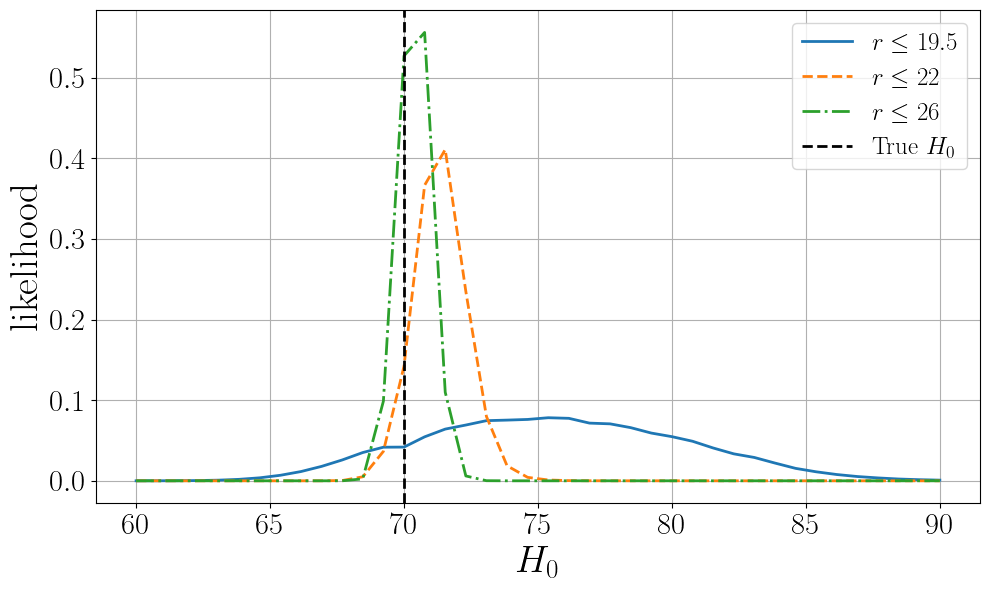

In [6]:
import matplotlib.pyplot as plt

def calculate_fractional_error(H0_true, H0_array, post):
    H0_mean = np.trapz(H0_array * post, H0_array)
    H0_std = np.sqrt(np.trapz((H0_array - H0_mean)**2 * post, H0_array))
    fractional_error = H0_std / H0_true
    return fractional_error

# print("Max log-likelihood (mag<19.5):", np.nanmax(res_H0_1))
# print("Max log-likelihood (mag<22.0):", np.nanmax(res_H0_2))
# print("Max log-likelihood (mag<26.0):", np.nanmax(res_H0_3))

print("Fractional error (mag<19.5):", calculate_fractional_error(cosmo.H0, H0, post_jax_1))
print("Fractional error (mag<22.0):", calculate_fractional_error(cosmo.H0, H0, post_jax_2))
print("Fractional error (mag<26.0):", calculate_fractional_error(cosmo.H0, H0, post_jax_3))

plt.style.use('~/research/my_plot_style.style')
plt.plot(H0, post_jax_1, label=r'$r \leq 19.5$', lw=2)
plt.plot(H0, post_jax_2, label=r'$r \leq 22$', lw=2, ls='--')
plt.plot(H0, post_jax_3, label=r'$r \leq 26$', lw=2, ls='-.')
plt.axvline(cosmo.H0, color='black', linestyle='--', label=r'True $H_0$')
plt.xlabel(r'$H_0$')
plt.ylabel('likelihood')
plt.legend()
plt.show()